# Sim Setup - computing and plotting power spectra

- Compute power spectra for each time series
- Plot the power spectra together, how do they relate to each other
- How do the power spectra vary when plotted with log vs linear freqs & powers

## Imports

In [1]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam import SpectralModel #This allows us to initialise and fit spectral models
from specparam.plts import plot_spectra # Plot one or multiple power spectra

from matplotlib import pyplot

## Data Simulation Settings

In [2]:
# First need to create a seed and simulation settings so that there is consistency in the simulated data
set_random_seed(57)

# Simulation settings
n_seconds = 5 # Number of seconds
s_rate = 500 # Sampling rate

# Compute an array of time values for plotting, and check length of data
times = create_times(n_seconds, s_rate)
n_points = len(times)

### Simulate signals

In [4]:
# Simulate a white noise time series signal 
white_signal = np.random.normal(0, 1, n_points)

# Simulate pink noise time series signal
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)

# Simulate brown noise time series signal 
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

### Power Spectra

In [5]:
# Compute white, pink and brown power spectras
w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)
p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)
b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

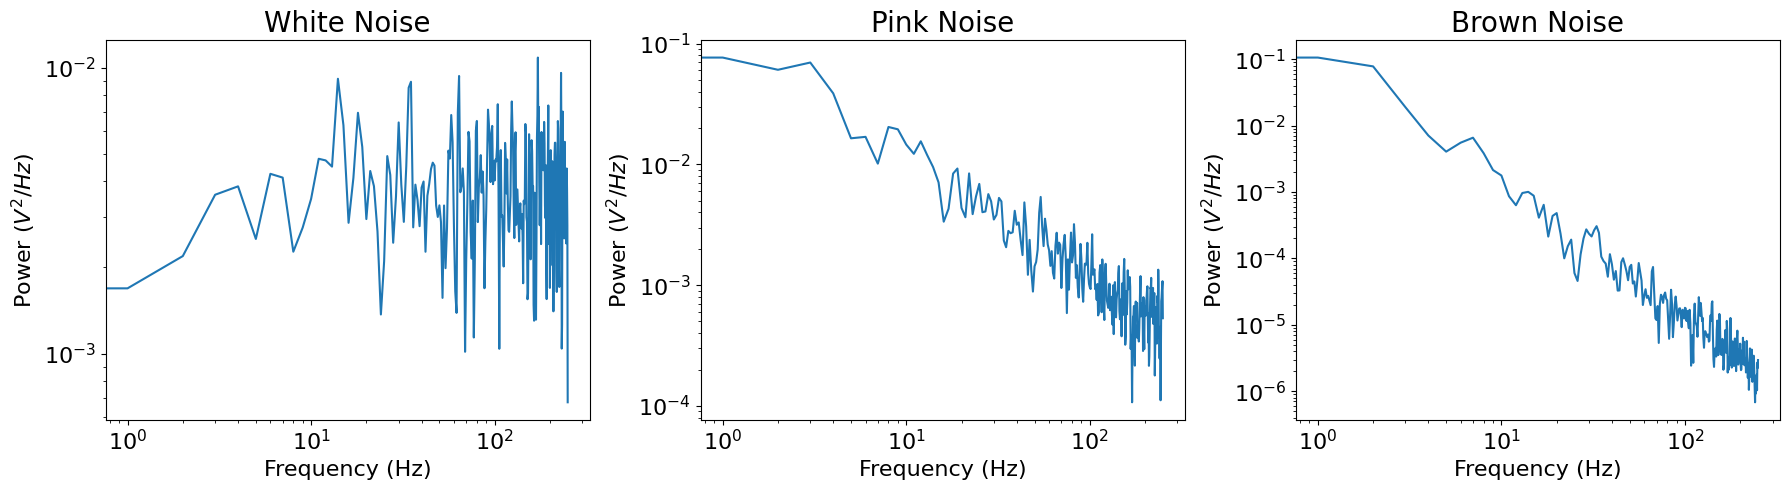

In [6]:
# Visualise white, pink and brown power spectras - log-log scale
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
plot_power_spectra(w_freqs, w_powers, title = "White Noise", ax=ax1)
plot_power_spectra(p_freqs, p_powers, title = "Pink Noise", ax=ax2)
plot_power_spectra(b_freqs, b_powers, title = "Brown Noise", ax=ax3)

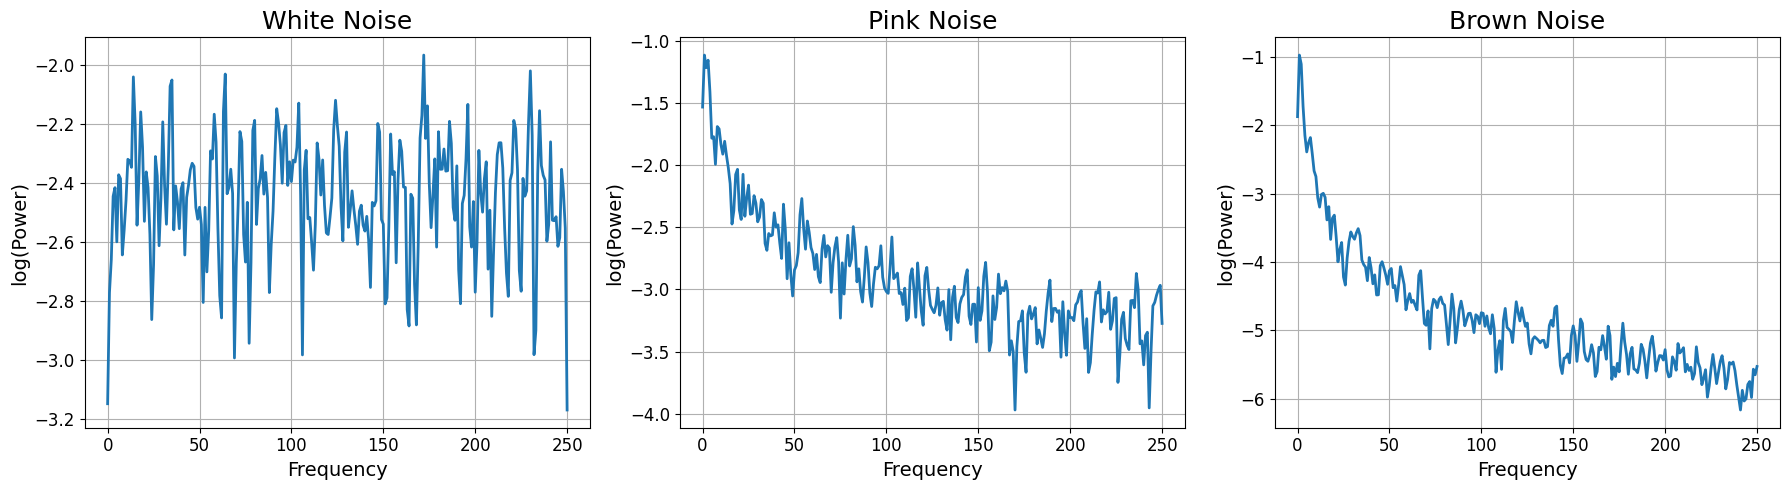

In [7]:
# Visualise white, pink and brown power spectras - frequency in linear scale
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
plot_spectra(w_freqs, w_powers, log_powers=True, title = "White Noise", ax=ax1)
plot_spectra(p_freqs, p_powers, log_powers=True, title = "Pink Noise", ax=ax2)
plot_spectra(b_freqs, b_powers, log_powers=True, title = "Brown Noise", ax=ax3)

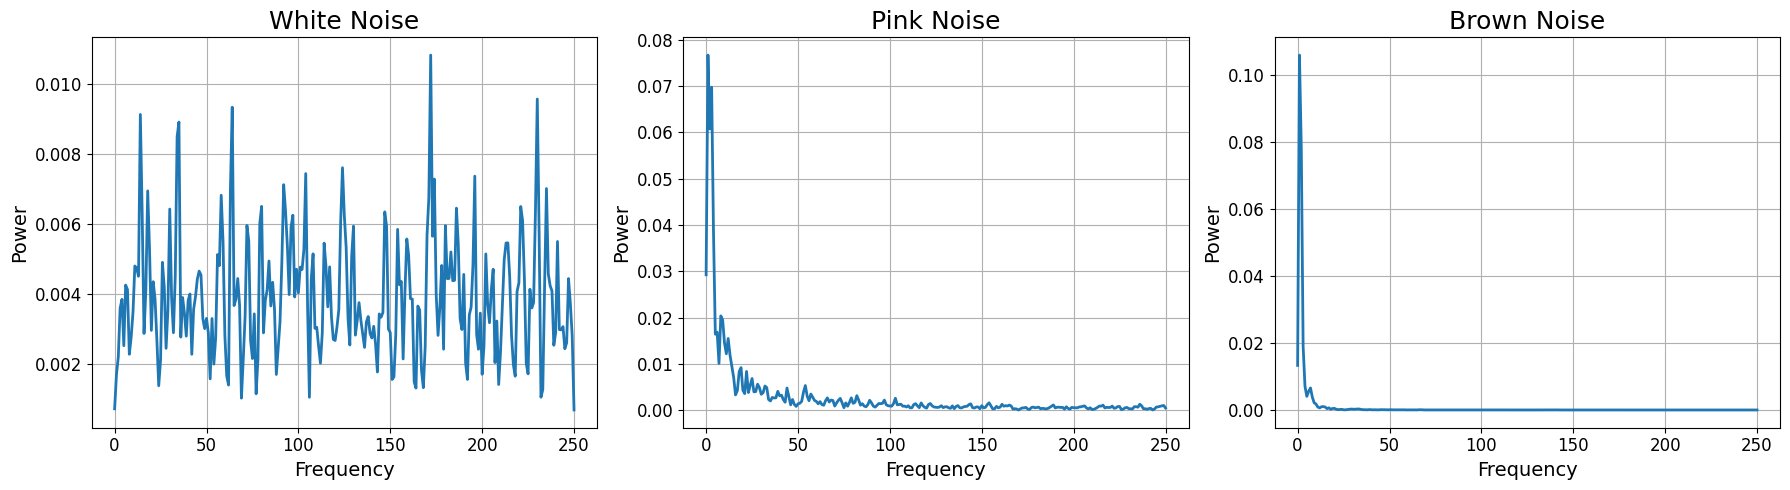

In [8]:
# Visualise white, pink and brown power spectras - linear scale
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
plot_spectra(w_freqs, w_powers, title = "White Noise", ax=ax1)
plot_spectra(p_freqs, p_powers, title = "Pink Noise", ax=ax2)
plot_spectra(b_freqs, b_powers, title = "Brown Noise", ax=ax3)